In [1]:
# Install all required libraries
# Run this cell first — only needed once per session
!pip install -q seaborn xgboost shap folium scikit-learn pandas numpy matplotlib imbalanced-learn


# Chicago Crime Intelligence: A Dual-Task Classification and Hotspot Detection Study
**Course:** INFO 6105 — Data Science Engineering Methods and Tools  
**Team:** 13 | **Members:** Amrin Bushra Taj, Anushika Balamurgan  
**Dataset:** Chicago Crimes 2008–2017 (~450 MB, ~1.5M records)  

### Three Tasks:
- **Task 1:** Predict arrest outcome (binary classification)
- **Task 2:** Geospatial crime hotspot detection (DBSCAN + KMeans)
- **Task 3:** Predict primary crime type (multi-class classification)

### Four Models:
Logistic Regression | Decision Tree | Random Forest | XGBoost

---
## Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ModuleNotFoundError:
    print('Warning: xgboost is not installed. Skipping XGBoost models.')
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

# Clustering
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_recall_curve
)

# Imbalanced-learn — for SMOTE resampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# SHAP
import shap

# Folium map
import folium
from folium.plugins import HeatMap

print('All libraries imported successfully!')


All libraries imported successfully!


---
## Step 2: Data Ingestion and Merging
Loading two CSV files (2001–2004 and 2005–2007) and concatenating into one DataFrame.

In [3]:
# ── UPDATE THESE PATHS to your local files ──────────────────────
FILE_1 = '/content/Chicago_Crimes_2008_to_2011.csv'
FILE_2 = '/content/Chicago_Crimes_2012_to_2017.csv'
# ────────────────────────────────────────────────────────────────

print('Loading files...')
df1 = pd.read_csv(FILE_1, low_memory=False, on_bad_lines='skip')
df2 = pd.read_csv(FILE_2, low_memory=False, on_bad_lines='skip')

# Concatenate into single DataFrame
df = pd.concat([df1, df2], ignore_index=True)
del df1, df2   # free memory immediately

print(f'Combined shape    : {df.shape}')
print(f'Memory usage      : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Columns           : {list(df.columns)}')

Loading files...
Combined shape    : (553879, 23)
Memory usage      : 421.0 MB
Columns           : ['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


In [4]:
# Quick sanity checks
print('Shape :', df.shape)
df.head(3)

Shape : (553879, 23)


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,388,4785,HP610824,10/07/2008 12:39:00 PM,000XX E 75TH ST,0110,HOMICIDE,FIRST DEGREE MURDER,ALLEY,True,...,6.0,69.0,01A,1178207.0,1855308.0,2008.0,08/17/2015 03:03:40 PM,41.758276,-87.622451,"(41.758275857, -87.622451031)"
1,835,4786,HP616595,10/09/2008 03:30:00 AM,048XX W POLK ST,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,...,24.0,25.0,01A,1144200.0,1895857.0,2008.0,08/17/2015 03:03:40 PM,41.870252,-87.746069,"(41.87025207, -87.746069362)"
2,1334,4787,HP616904,10/09/2008 08:35:00 AM,030XX W MANN DR,0110,HOMICIDE,FIRST DEGREE MURDER,PARK PROPERTY,False,...,18.0,66.0,01A,1157314.0,1859778.0,2008.0,08/17/2015 03:03:40 PM,41.770990,-87.698901,"(41.770990476, -87.698901469)"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553879 entries, 0 to 553878
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            553879 non-null  int64  
 1   ID                    553879 non-null  int64  
 2   Case Number           553879 non-null  object 
 3   Date                  553879 non-null  object 
 4   Block                 553879 non-null  object 
 5   IUCR                  553879 non-null  object 
 6   Primary Type          553879 non-null  object 
 7   Description           553879 non-null  object 
 8   Location Description  553567 non-null  object 
 9   Arrest                553879 non-null  bool   
 10  Domestic              553879 non-null  bool   
 11  Beat                  553879 non-null  int64  
 12  District              553877 non-null  float64
 13  Ward                  553869 non-null  float64
 14  Community Area        553637 non-null  float64
 15  

In [6]:
df.describe(include='all')

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
count,5.538790e+05,5.538790e+05,553879,553879,553879,553879,553879,553879,553567,553879,...,553869.000000,553637.000000,553878,5.322970e+05,5.322970e+05,553878.000000,553878,532297.000000,532297.000000,532296
unique,NaN,NaN,553860,232216,30178,357,32,333,121,2,...,NaN,NaN,26,NaN,NaN,NaN,252,NaN,276929.000000,222683
top,NaN,NaN,HZ140230,01/01/2008 12:01:00 AM,100XX W OHARE ST,0486,THEFT,SIMPLE,STREET,False,...,NaN,NaN,06,NaN,NaN,NaN,02/04/2016 06:33:39 AM,NaN,-87.905227,"(41.976290414, -87.905227221)"
freq,NaN,NaN,5,222,1256,49393,115656,59738,137139,405930,...,NaN,NaN,115656,NaN,NaN,NaN,463735,NaN,1033.000000,1158
mean,1.542224e+06,7.670270e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.641957,37.897769,NaN,1.164500e+06,1.884994e+06,2010.510580,NaN,41.840018,NaN,NaN
std,7.559522e+05,1.484430e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.740871,21.553759,NaN,1.869991e+04,3.474868e+04,2.632443,NaN,0.095689,NaN,NaN
min,3.000000e+00,4.785000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,NaN,0.000000e+00,0.000000e+00,2008.000000,NaN,36.619446,NaN,NaN
25%,9.356235e+05,6.241940e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.000000,23.000000,NaN,1.152721e+06,1.858321e+06,2008.000000,NaN,41.766513,NaN,NaN
50%,1.074093e+06,8.437168e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.000000,32.000000,NaN,1.166031e+06,1.889529e+06,2012.000000,NaN,41.852490,NaN,NaN
75%,2.478422e+06,8.661154e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.000000,58.000000,NaN,1.176369e+06,1.908946e+06,2012.000000,NaN,41.905844,NaN,NaN


In [7]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Latitude,21582,3.90
Longitude,21582,3.90
Y Coordinate,21582,3.90
X Coordinate,21582,3.90
Location,21583,3.90
Location Description,312,0.06
Community Area,242,0.04
District,2,0.00
Ward,10,0.00
FBI Code,1,0.00


---
## Step 3: Exploratory Data Analysis (EDA)

In [8]:
# 3.1 — Parse datetime and extract temporal features early (needed for EDA)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Hour']       = df['Date'].dt.hour
df['DayOfWeek']  = df['Date'].dt.dayofweek   # 0=Mon, 6=Sun
df['Month']      = df['Date'].dt.month
df['Year']       = df['Date'].dt.year
print('Datetime features created: Hour, DayOfWeek, Month, Year')

Datetime features created: Hour, DayOfWeek, Month, Year


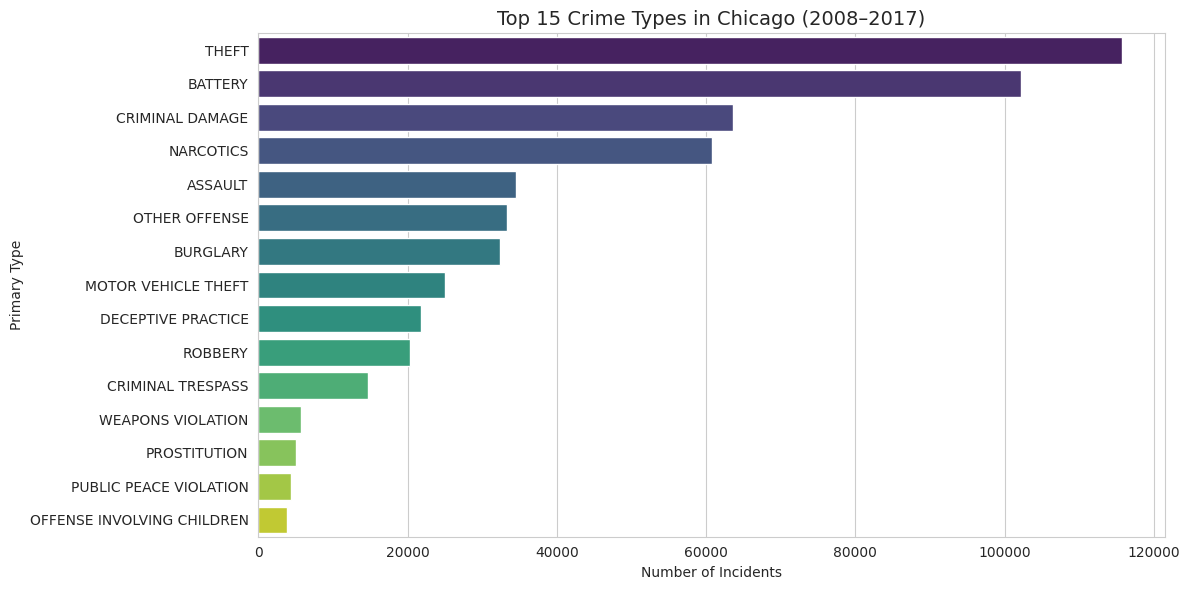

Primary Type
THEFT                         115656
BATTERY                       102195
CRIMINAL DAMAGE                63571
NARCOTICS                      60824
ASSAULT                        34521
OTHER OFFENSE                  33354
BURGLARY                       32427
MOTOR VEHICLE THEFT            25000
DECEPTIVE PRACTICE             21866
ROBBERY                        20314
CRIMINAL TRESPASS              14693
WEAPONS VIOLATION               5771
PROSTITUTION                    5000
PUBLIC PEACE VIOLATION          4411
OFFENSE INVOLVING CHILDREN      3848
Name: count, dtype: int64


In [9]:
# 3.2 — Top 15 crime types
top15 = df['Primary Type'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top15.values, y=top15.index, palette='viridis')
plt.title('Top 15 Crime Types in Chicago (2008–2017)', fontsize=14)
plt.xlabel('Number of Incidents')
plt.tight_layout()
plt.show()
print(top15)

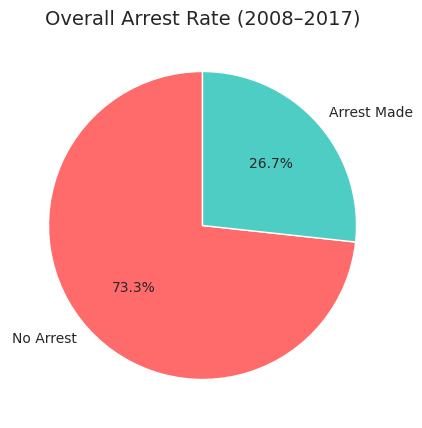

Arrest
False    405930
True     147949
Name: count, dtype: int64


In [10]:
# 3.3 — Overall arrest rate (pie chart)
arrest_counts = df['Arrest'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(arrest_counts, labels=['No Arrest', 'Arrest Made'],
        autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'], startangle=90)
plt.title('Overall Arrest Rate (2008–2017)', fontsize=14)
plt.show()
print(arrest_counts)

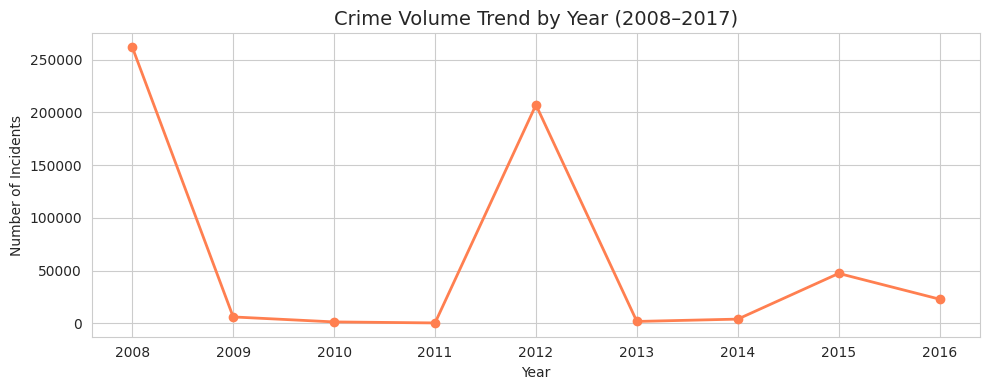

In [11]:
# 3.4 — Crime volume trend by year
plt.figure(figsize=(10, 4))
df.groupby('Year').size().plot(kind='line', marker='o', color='coral', linewidth=2)
plt.title('Crime Volume Trend by Year (2008–2017)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

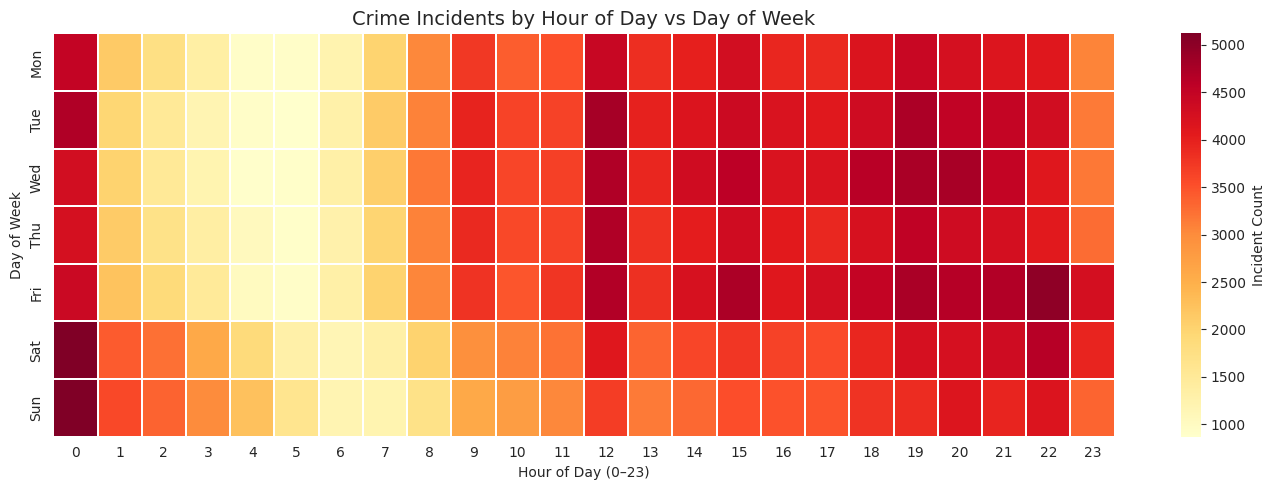

In [12]:
# 3.5 — Hour-of-day vs Day-of-week heatmap
pivot = df.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            yticklabels=day_labels, cbar_kws={'label': 'Incident Count'})
plt.title('Crime Incidents by Hour of Day vs Day of Week', fontsize=14)
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

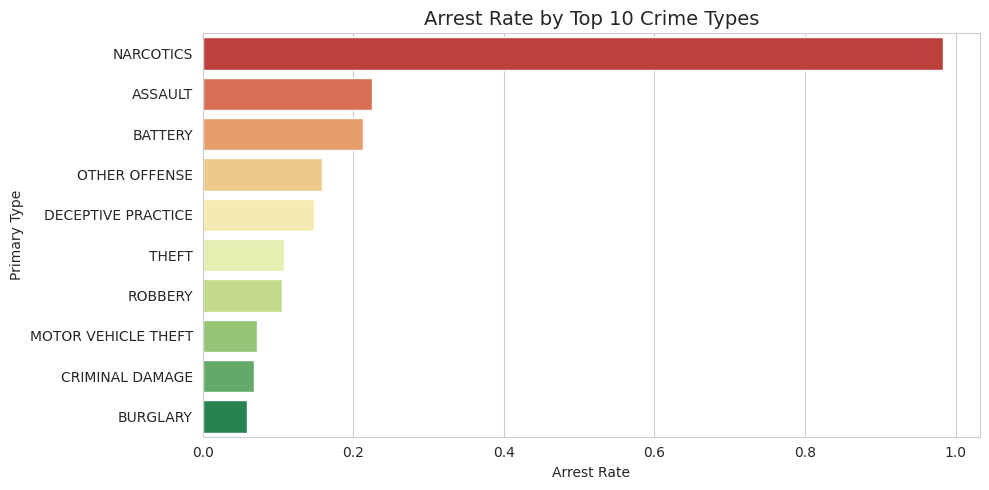

In [13]:
# 3.6 — Arrest rate by top 10 crime types
top10_types = df['Primary Type'].value_counts().head(10).index
arrest_by_type = (
    df[df['Primary Type'].isin(top10_types)]
    .groupby('Primary Type')['Arrest']
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 5))
sns.barplot(x=arrest_by_type.values, y=arrest_by_type.index, palette='RdYlGn')
plt.title('Arrest Rate by Top 10 Crime Types', fontsize=14)
plt.xlabel('Arrest Rate')
plt.tight_layout()
plt.show()

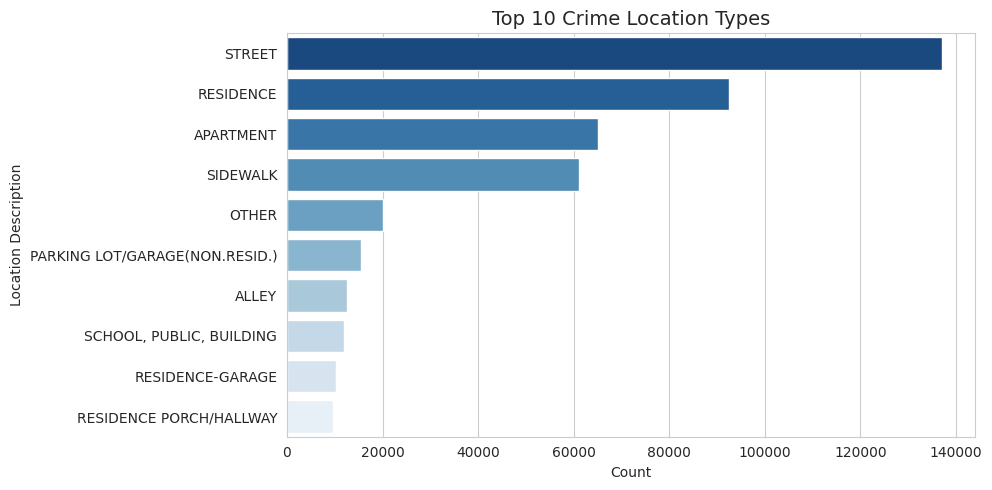

In [14]:
# 3.7 — Top 10 location descriptions
top_locs = df['Location Description'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_locs.values, y=top_locs.index, palette='Blues_r')
plt.title('Top 10 Crime Location Types', fontsize=14)
plt.xlabel('Count')
plt.tight_layout()
plt.show()

---
## Step 4: Data Cleaning

In [15]:
# 4.1 — Drop irrelevant columns
DROP_COLS = ['ID', 'Case Number', 'Date', 'Updated On', 'Description',
             'X Coordinate', 'Y Coordinate', 'Location', 'Block']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Convert Latitude and Longitude to numeric, coercing errors
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# 4.2 — Drop rows with nulls in key columns
KEY_COLS = ['Primary Type', 'Arrest', 'Latitude', 'Longitude',
            'District', 'Location Description']
df.dropna(subset=[c for c in KEY_COLS if c in df.columns], inplace=True)

# 4.3 — Drop duplicates
df.drop_duplicates(inplace=True)

# 4.4 — Filter to top 10 crime types (Task 3 label space)
TOP_N = 10
top_crime_types = df['Primary Type'].value_counts().head(TOP_N).index
df = df[df['Primary Type'].isin(top_crime_types)].copy()

# 4.5 — Filter valid Chicago coordinates
df = df[
    df['Latitude'].between(41.6, 42.1) &
    df['Longitude'].between(-87.9, -87.5)
].copy()

print(f'Cleaned dataset shape: {df.shape}')
print(f'Top {TOP_N} crime types retained: {list(top_crime_types)}')

Cleaned dataset shape: (488157, 17)
Top 10 crime types retained: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'NARCOTICS', 'ASSAULT', 'OTHER OFFENSE', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'ROBBERY', 'DECEPTIVE PRACTICE']


---
## Step 5: Feature Engineering

In [16]:
le = LabelEncoder()

# Encode categorical features
for col in ['Location Description', 'FBI Code']:
    if col in df.columns:
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Boolean to int
if 'Domestic' in df.columns:
    df['Domestic'] = df['Domestic'].astype(int)

# Target: Task 1 — Arrest (binary)
df['Arrest'] = df['Arrest'].astype(int)

# Target: Task 3 — Crime Type (multi-class)
df['Crime_Type_enc'] = le.fit_transform(df['Primary Type'])
crime_type_classes = le.classes_

print('Feature engineering complete.')
print(f'Crime type classes: {list(crime_type_classes)}')
df.head(3)

Feature engineering complete.
Crime type classes: ['ASSAULT', 'BATTERY', 'BURGLARY', 'CRIMINAL DAMAGE', 'DECEPTIVE PRACTICE', 'MOTOR VEHICLE THEFT', 'NARCOTICS', 'OTHER OFFENSE', 'ROBBERY', 'THEFT']


,Unnamed: 0,IUCR,Primary Type,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Latitude,Longitude,Hour,DayOfWeek,Month,Location Description_enc,FBI Code_enc,Crime_Type_enc
95,58331,041A,BATTERY,SIDEWALK,0,0,2424,24.0,49.0,1.0,04B,2008,42.019439,-87.679653,2,6,4,89,2,1
404,708812,0460,BATTERY,STREET,0,0,1832,18.0,42.0,8.0,08B,2008,41.893201,-87.633195,3,0,1,92,7,1
1093,763075,0810,THEFT,STREET,0,0,113,1.0,42.0,32.0,06,2008,41.886817,-87.630352,6,3,2,92,4,9


---
## Step 6: Preprocessing — Sample, Scale, Split

In [17]:
# Feature set (shared across Task 1 and Task 3)
FEATURES = ['Hour', 'DayOfWeek', 'Month', 'Year',
            'Latitude', 'Longitude', 'Domestic',
            'Location Description_enc']
for col in ['District', 'Ward', 'Beat', 'Community Area', 'FBI Code_enc']:
    if col in df.columns:
        FEATURES.append(col)

X_full = df[FEATURES].fillna(0)
y1_full = df['Arrest']          # Task 1
y3_full = df['Crime_Type_enc']  # Task 3

print(f'Full feature matrix : {X_full.shape}')
print(f'Task 1 class balance:\n{y1_full.value_counts()}')
print(f'Task 3 classes      : {y3_full.nunique()}')

Full feature matrix : (488157, 13)
Task 1 class balance:
Arrest
0    371750
1    116407
Name: count, dtype: int64
Task 3 classes      : 10


In [18]:
# Stratified sample of 150,000 records (as per proposal)
SAMPLE_SIZE = 150_000
sample_idx = X_full.sample(n=min(SAMPLE_SIZE, len(X_full)), random_state=42).index
X = X_full.loc[sample_idx]
y1 = y1_full.loc[sample_idx]
y3 = y3_full.loc[sample_idx]

print(f'Sampled to {len(X):,} records for training')

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 stratified splits
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_scaled, y1, test_size=0.2, random_state=42, stratify=y1)
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_scaled, y3, test_size=0.2, random_state=42, stratify=y3)

print(f'Task 1 — Train: {X_tr1.shape}, Test: {X_te1.shape}')
print(f'Task 3 — Train: {X_tr3.shape}, Test: {X_te3.shape}')

# ── SMOTE resampling for Task 1 (fixes 75/25 class imbalance) ──────────
# Step 1: oversample minority (Arrest=1) to 50% ratio with SMOTE
# Step 2: undersample majority back to 80% to keep dataset manageable
print('\nApplying SMOTE + RandomUnderSampler for Task 1...')
over  = SMOTE(sampling_strategy=0.5, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.8, random_state=42)
X_tr1_res, y_tr1_res = over.fit_resample(X_tr1, y_tr1)
X_tr1_res, y_tr1_res = under.fit_resample(X_tr1_res, y_tr1_res)

# Compute scale_pos_weight for XGBoost (ratio of negatives to positives)
neg_count = (y_tr1 == 0).sum()
pos_count = (y_tr1 == 1).sum()
SCALE_POS_WEIGHT = neg_count / pos_count
print(f'Class ratio (neg/pos) = {SCALE_POS_WEIGHT:.2f}  →  scale_pos_weight for XGBoost')
print(f'Resampled Task 1 train shape: {X_tr1_res.shape}')
print(f'Resampled class distribution: {dict(zip(*np.unique(y_tr1_res, return_counts=True)))}')


Sampled to 150,000 records for training
Task 1 — Train: (120000, 13), Test: (30000, 13)
Task 3 — Train: (120000, 13), Test: (30000, 13)

Applying SMOTE + RandomUnderSampler for Task 1...
Class ratio (neg/pos) = 3.19  →  scale_pos_weight for XGBoost
Resampled Task 1 train shape: (102759, 13)
Resampled class distribution: {np.int64(0): np.int64(57088), np.int64(1): np.int64(45671)}


---
## Step 7: Task 1 — Arrest Outcome Prediction (Binary Classification)
### 7.1 Logistic Regression

In [19]:
# ── IMPROVEMENT: class_weight='balanced' corrects for 75/25 imbalance ──
lr1 = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1,
                          class_weight='balanced')
lr1.fit(X_tr1, y_tr1)   # trained on original (balanced weighting handles it)
ypr_lr1 = lr1.predict_proba(X_te1)[:, 1]

# ── THRESHOLD TUNING: find threshold that maximises Arrest-class F1 ────
precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_te1, ypr_lr1)
f1s_lr = 2 * precisions_lr * recalls_lr / (precisions_lr + recalls_lr + 1e-9)
best_thresh_lr = thresholds_lr[f1s_lr[:-1].argmax()]
print(f'Best threshold (LR): {best_thresh_lr:.3f}')

yp_lr1  = (ypr_lr1 >= best_thresh_lr).astype(int)
acc_lr1 = accuracy_score(y_te1, yp_lr1)
auc_lr1 = roc_auc_score(y_te1, ypr_lr1)
f1_arrest_lr1 = f1_score(y_te1, yp_lr1, pos_label=1)
print(f'Logistic Regression  — Accuracy: {acc_lr1:.4f} | ROC-AUC: {auc_lr1:.4f} | Arrest F1: {f1_arrest_lr1:.4f}')
print(classification_report(y_te1, yp_lr1, target_names=['No Arrest', 'Arrest']))


Best threshold (LR): 0.662
Logistic Regression  — Accuracy: 0.7895 | ROC-AUC: 0.7181 | Arrest F1: 0.5334
              precision    recall  f1-score   support

   No Arrest       0.85      0.88      0.86     22836
      Arrest       0.57      0.50      0.53      7164

    accuracy                           0.79     30000
   macro avg       0.71      0.69      0.70     30000
weighted avg       0.78      0.79      0.79     30000



### 7.2 Decision Tree

In [20]:
# ── IMPROVEMENT: class_weight='balanced' + deeper tree for Arrest recall ─
dt1 = DecisionTreeClassifier(max_depth=12, random_state=42,
                              class_weight='balanced',
                              min_samples_leaf=20)
dt1.fit(X_tr1, y_tr1)
ypr_dt1 = dt1.predict_proba(X_te1)[:, 1]

# Threshold tuning
precisions_dt, recalls_dt, thresholds_dt = precision_recall_curve(y_te1, ypr_dt1)
f1s_dt = 2 * precisions_dt * recalls_dt / (precisions_dt + recalls_dt + 1e-9)
best_thresh_dt = thresholds_dt[f1s_dt[:-1].argmax()]
print(f'Best threshold (DT): {best_thresh_dt:.3f}')

yp_dt1  = (ypr_dt1 >= best_thresh_dt).astype(int)
acc_dt1 = accuracy_score(y_te1, yp_dt1)
auc_dt1 = roc_auc_score(y_te1, ypr_dt1)
f1_arrest_dt1 = f1_score(y_te1, yp_dt1, pos_label=1)
print(f'Decision Tree        — Accuracy: {acc_dt1:.4f} | ROC-AUC: {auc_dt1:.4f} | Arrest F1: {f1_arrest_dt1:.4f}')
print(classification_report(y_te1, yp_dt1, target_names=['No Arrest', 'Arrest']))


Best threshold (DT): 0.680
Decision Tree        — Accuracy: 0.8715 | ROC-AUC: 0.8680 | Arrest F1: 0.6948
              precision    recall  f1-score   support

   No Arrest       0.89      0.95      0.92     22836
      Arrest       0.80      0.61      0.69      7164

    accuracy                           0.87     30000
   macro avg       0.84      0.78      0.81     30000
weighted avg       0.87      0.87      0.87     30000



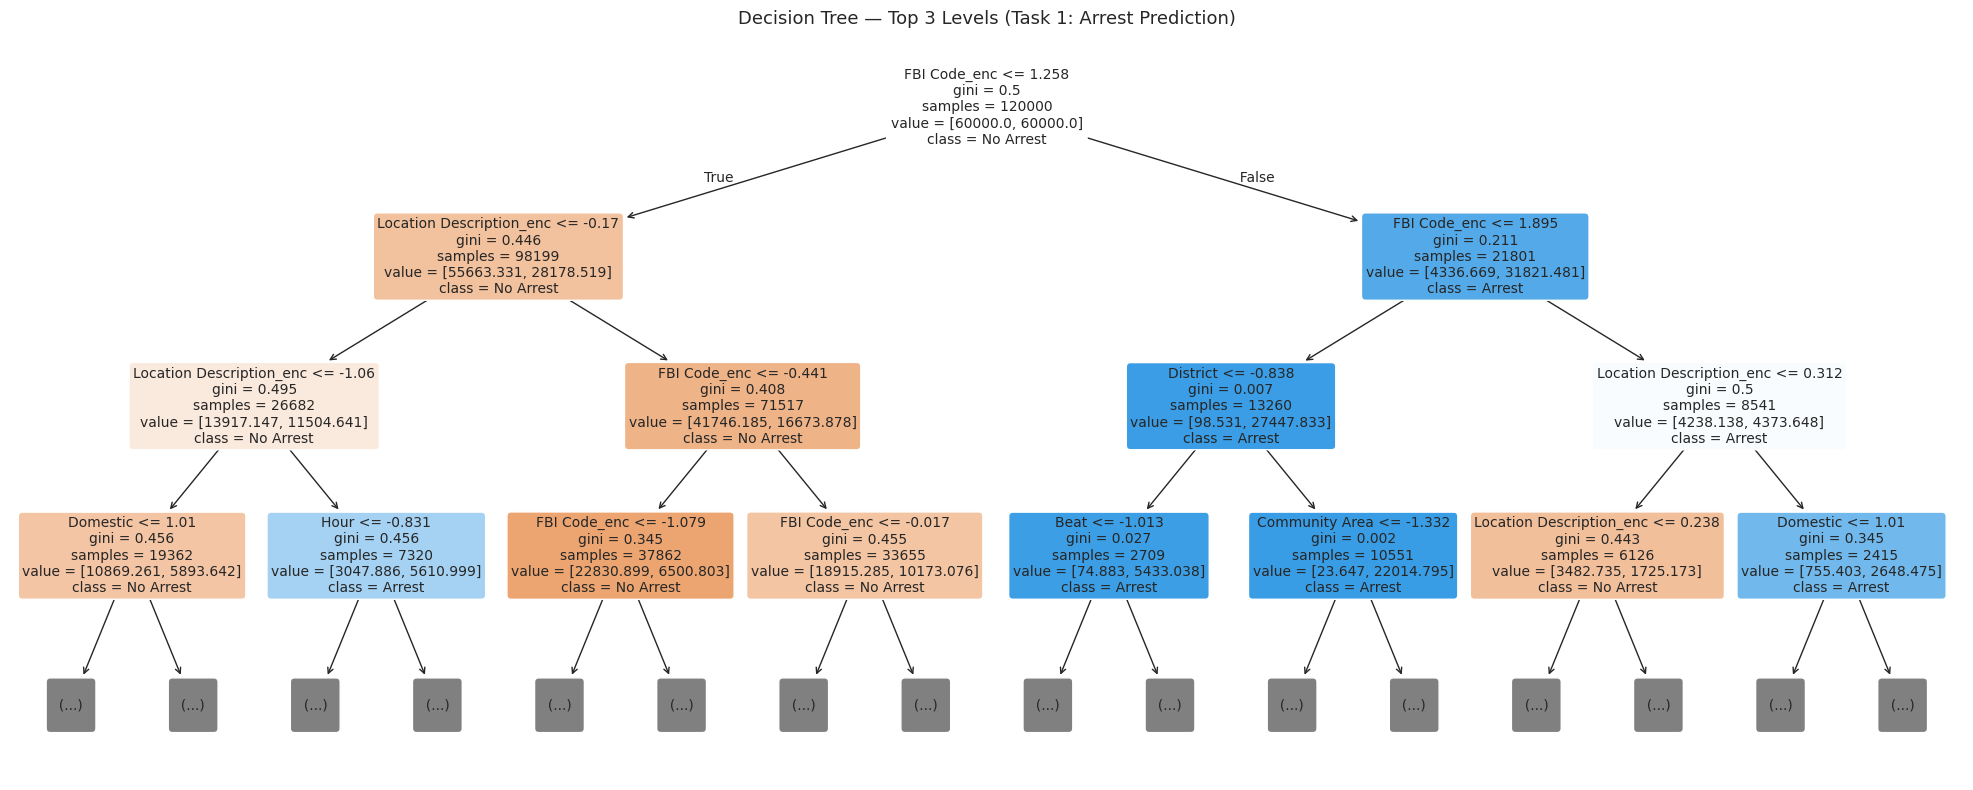

In [21]:
# Decision Tree — top decision nodes visualization
plt.figure(figsize=(20, 8))
plot_tree(dt1, max_depth=3, feature_names=FEATURES,
          class_names=['No Arrest', 'Arrest'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree — Top 3 Levels (Task 1: Arrest Prediction)', fontsize=13)
plt.tight_layout()
plt.show()

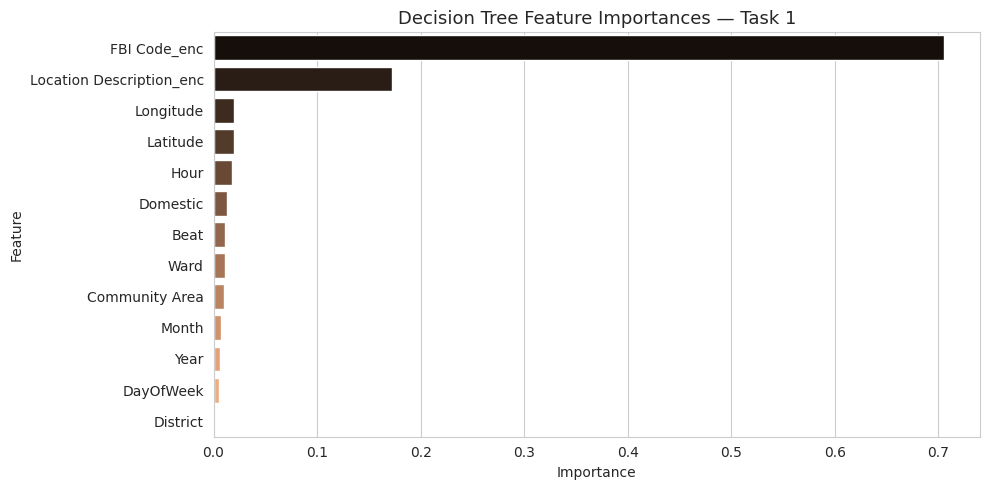

In [22]:
# Decision Tree — feature importance
fi_dt1 = pd.DataFrame({'Feature': FEATURES, 'Importance': dt1.feature_importances_})
fi_dt1 = fi_dt1.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=fi_dt1, palette='copper')
plt.title('Decision Tree Feature Importances — Task 1', fontsize=13)
plt.tight_layout()
plt.show()

### 7.3 Random Forest

In [23]:
# ── IMPROVEMENT: class_weight='balanced_subsample' + more trees ────────
rf1 = RandomForestClassifier(n_estimators=100, max_depth=12,
                              random_state=42, n_jobs=-1,
                              class_weight='balanced_subsample',
                              min_samples_leaf=10)
rf1.fit(X_tr1, y_tr1)
ypr_rf1 = rf1.predict_proba(X_te1)[:, 1]

# Threshold tuning
precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_te1, ypr_rf1)
f1s_rf = 2 * precisions_rf * recalls_rf / (precisions_rf + recalls_rf + 1e-9)
best_thresh_rf = thresholds_rf[f1s_rf[:-1].argmax()]
print(f'Best threshold (RF): {best_thresh_rf:.3f}')

yp_rf1  = (ypr_rf1 >= best_thresh_rf).astype(int)
acc_rf1 = accuracy_score(y_te1, yp_rf1)
auc_rf1 = roc_auc_score(y_te1, ypr_rf1)
f1_arrest_rf1 = f1_score(y_te1, yp_rf1, pos_label=1)
print(f'Random Forest        — Accuracy: {acc_rf1:.4f} | ROC-AUC: {auc_rf1:.4f} | Arrest F1: {f1_arrest_rf1:.4f}')
print(classification_report(y_te1, yp_rf1, target_names=['No Arrest', 'Arrest']))


Best threshold (RF): 0.536
Random Forest        — Accuracy: 0.8768 | ROC-AUC: 0.8676 | Arrest F1: 0.6913
              precision    recall  f1-score   support

   No Arrest       0.88      0.97      0.92     22836
      Arrest       0.86      0.58      0.69      7164

    accuracy                           0.88     30000
   macro avg       0.87      0.77      0.81     30000
weighted avg       0.88      0.88      0.87     30000



### 7.4 XGBoost

In [24]:
# ── IMPROVEMENT: scale_pos_weight handles imbalance natively in XGBoost ─
xgb1 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT,   # key imbalance fix
    eval_metric='aucpr',                  # PR-AUC better for imbalanced
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb1.fit(X_tr1_res, y_tr1_res)   # trained on SMOTE-resampled data
ypr_xgb1 = xgb1.predict_proba(X_te1)[:, 1]

# Threshold tuning
precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_te1, ypr_xgb1)
f1s_xgb = 2 * precisions_xgb * recalls_xgb / (precisions_xgb + recalls_xgb + 1e-9)
best_thresh_xgb = thresholds_xgb[f1s_xgb[:-1].argmax()]
print(f'Best threshold (XGB): {best_thresh_xgb:.3f}')

yp_xgb1  = (ypr_xgb1 >= best_thresh_xgb).astype(int)
acc_xgb1 = accuracy_score(y_te1, yp_xgb1)
auc_xgb1 = roc_auc_score(y_te1, ypr_xgb1)
f1_arrest_xgb1 = f1_score(y_te1, yp_xgb1, pos_label=1)
print(f'XGBoost              — Accuracy: {acc_xgb1:.4f} | ROC-AUC: {auc_xgb1:.4f} | Arrest F1: {f1_arrest_xgb1:.4f}')
print(classification_report(y_te1, yp_xgb1, target_names=['No Arrest', 'Arrest']))


Best threshold (XGB): 0.750
XGBoost              — Accuracy: 0.8765 | ROC-AUC: 0.8780 | Arrest F1: 0.6964
              precision    recall  f1-score   support

   No Arrest       0.88      0.97      0.92     22836
      Arrest       0.84      0.59      0.70      7164

    accuracy                           0.88     30000
   macro avg       0.86      0.78      0.81     30000
weighted avg       0.87      0.88      0.87     30000



### 7.5 Task 1 — Precision-Recall Curves + ROC Curves + Model Comparison


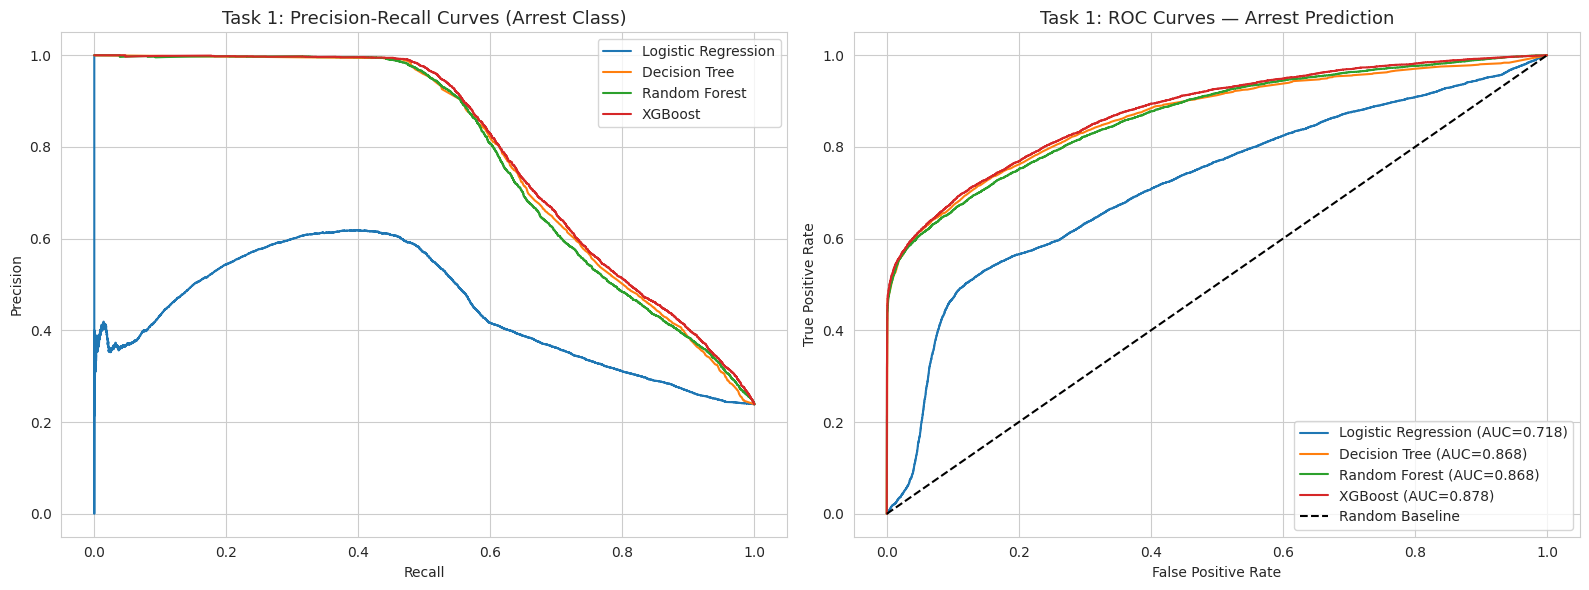

In [25]:
# Precision-Recall curves (more informative than ROC for imbalanced data)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_data = [
    ('Logistic Regression', ypr_lr1),
    ('Decision Tree',       ypr_dt1),
    ('Random Forest',       ypr_rf1),
    ('XGBoost',             ypr_xgb1),
]

# Left: Precision-Recall curves
for name, ypr in model_data:
    p, r, _ = precision_recall_curve(y_te1, ypr)
    f1_val = f1_score(y_te1, (ypr >= 0.5).astype(int), pos_label=1)
    axes[0].plot(r, p, label=f'{name}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Task 1: Precision-Recall Curves (Arrest Class)', fontsize=13)
axes[0].legend()

# Right: ROC curves
for name, ypr in model_data:
    fpr, tpr, _ = roc_curve(y_te1, ypr)
    auc = roc_auc_score(y_te1, ypr)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Task 1: ROC Curves — Arrest Prediction', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()


=== Task 1: Arrest Prediction — Model Comparison (with Arrest F1) ===
              Model  Accuracy  ROC-AUC  Arrest F1
            XGBoost    0.8765   0.8780     0.6964
      Decision Tree    0.8715   0.8680     0.6948
      Random Forest    0.8768   0.8676     0.6913
Logistic Regression    0.7895   0.7181     0.5334


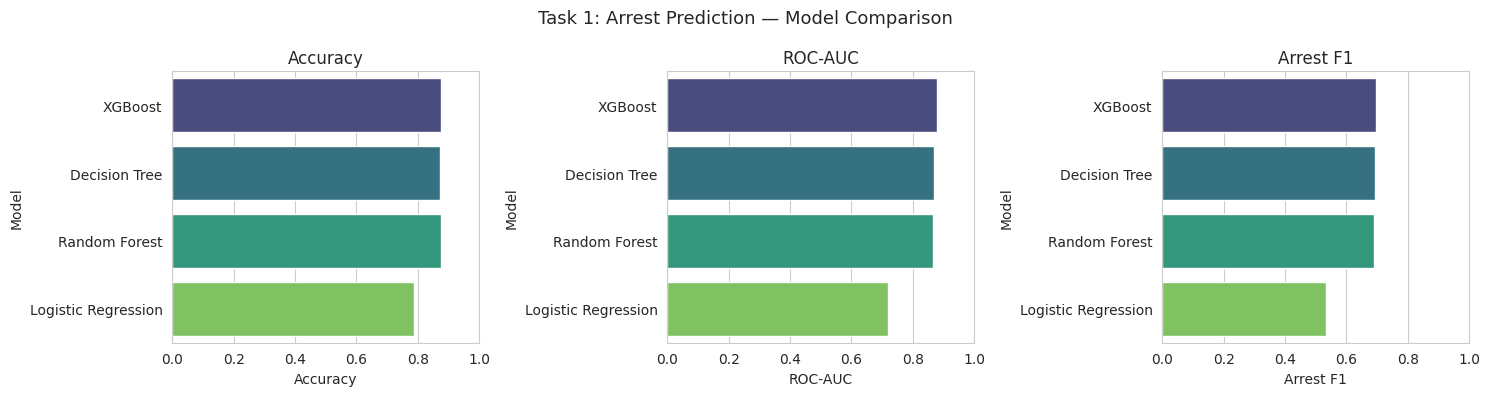

In [26]:
# Task 1 comparison table — includes Arrest F1 as key metric
results1 = pd.DataFrame({
    'Model':      ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy':   [acc_lr1, acc_dt1, acc_rf1, acc_xgb1],
    'ROC-AUC':    [auc_lr1, auc_dt1, auc_rf1, auc_xgb1],
    'Arrest F1':  [f1_arrest_lr1, f1_arrest_dt1, f1_arrest_rf1, f1_arrest_xgb1],
}).sort_values('Arrest F1', ascending=False)

print('=== Task 1: Arrest Prediction — Model Comparison (with Arrest F1) ===')
print(results1.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC', 'Arrest F1']):
    sns.barplot(x=metric, y='Model', data=results1, palette='viridis', ax=ax)
    ax.set_title(metric); ax.set_xlim(0, 1)
plt.suptitle('Task 1: Arrest Prediction — Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 8: Task 2 — Geospatial Hotspot Detection (DBSCAN + KMeans)

In [27]:
# Prepare coordinates — use full cleaned df, sample 50k for speed
geo_df = df[['Latitude', 'Longitude', 'Primary Type', 'Arrest']].copy()
if len(geo_df) > 50_000:
    geo_df = geo_df.sample(n=50_000, random_state=42)

coords     = geo_df[['Latitude', 'Longitude']].values
coords_rad = np.radians(coords)   # for haversine
print(f'Coordinates ready: {len(coords):,} points')

Coordinates ready: 50,000 points


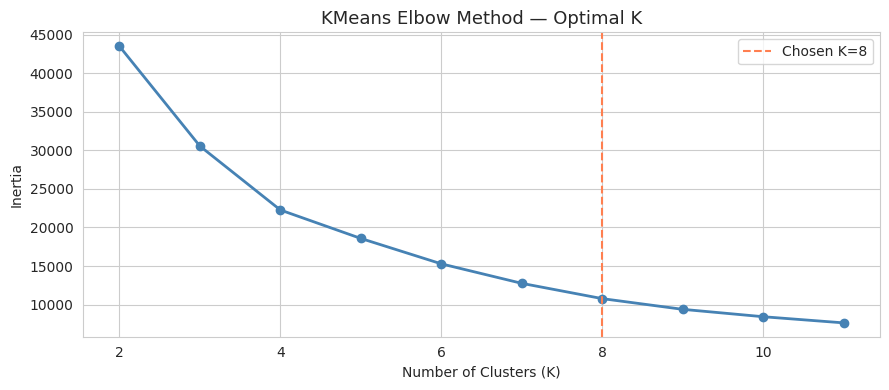

In [28]:
# KMeans — Elbow method
from sklearn.preprocessing import StandardScaler as SS
coords_scaled = SS().fit_transform(coords)

inertia = []
K_range = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=8, color='coral', linestyle='--', label='Chosen K=8')
plt.title('KMeans Elbow Method — Optimal K', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# KMeans — fit with K=8
K_OPTIMAL = 8
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
geo_df['kmeans_cluster'] = kmeans.fit_predict(coords_scaled)

sil_km = silhouette_score(coords_scaled, geo_df['kmeans_cluster'], sample_size=10_000)
print(f'KMeans Silhouette Score : {sil_km:.4f}')
print('Cluster sizes:')
print(geo_df['kmeans_cluster'].value_counts().sort_index())

KMeans Silhouette Score : 0.4012
Cluster sizes:
kmeans_cluster
0    4402
1    8449
2    6533
3    4382
4    8717
5    5893
6    5218
7    6406
Name: count, dtype: int64


In [30]:
# DBSCAN — haversine metric
dbscan = DBSCAN(
    eps=0.0008,        # ~88 metres
    min_samples=50,
    algorithm='ball_tree',
    metric='haversine',
    n_jobs=-1
)
geo_df['dbscan_cluster'] = dbscan.fit_predict(coords_rad)

n_clusters = len(set(geo_df['dbscan_cluster'])) - (1 if -1 in geo_df['dbscan_cluster'].values else 0)
n_noise    = (geo_df['dbscan_cluster'] == -1).sum()
print(f'DBSCAN hotspot clusters : {n_clusters}')
print(f'Noise points (isolated) : {n_noise:,} ({n_noise/len(geo_df)*100:.1f}%)')

DBSCAN hotspot clusters : 1
Noise points (isolated) : 0 (0.0%)


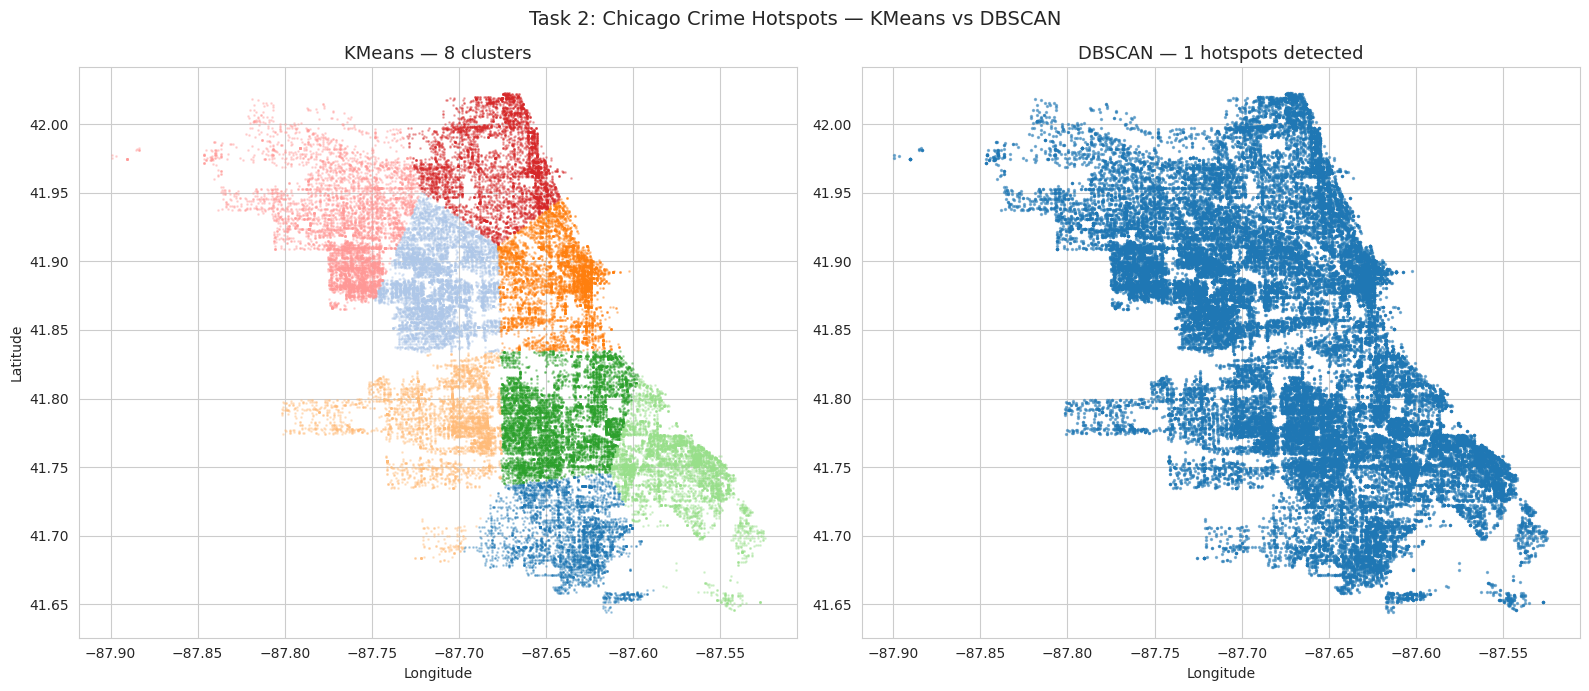

In [31]:
# Side-by-side static map comparison
colors = plt.cm.tab20.colors
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for cid in range(K_OPTIMAL):
    m = geo_df['kmeans_cluster'] == cid
    axes[0].scatter(geo_df.loc[m, 'Longitude'], geo_df.loc[m, 'Latitude'],
                    s=1, alpha=0.3, color=colors[cid % 20])
axes[0].set_title(f'KMeans — {K_OPTIMAL} clusters', fontsize=13)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

noise_m   = geo_df['dbscan_cluster'] == -1
cluster_m = ~noise_m
axes[1].scatter(geo_df.loc[noise_m, 'Longitude'], geo_df.loc[noise_m, 'Latitude'],
                s=1, alpha=0.1, color='lightgray', label='Noise')
for cid in sorted(geo_df.loc[cluster_m, 'dbscan_cluster'].unique())[:20]:
    m = geo_df['dbscan_cluster'] == cid
    axes[1].scatter(geo_df.loc[m, 'Longitude'], geo_df.loc[m, 'Latitude'],
                    s=2, alpha=0.5, color=colors[cid % 20])
axes[1].set_title(f'DBSCAN — {n_clusters} hotspots detected', fontsize=13)
axes[1].set_xlabel('Longitude')

plt.suptitle('Task 2: Chicago Crime Hotspots — KMeans vs DBSCAN', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# Interactive Folium heatmap
chicago_map = folium.Map(location=[41.85, -87.65], zoom_start=11,
                          tiles='CartoDB dark_matter')
heat_data = geo_df[['Latitude', 'Longitude']].values.tolist()
HeatMap(heat_data, radius=10, blur=8, max_zoom=13,
        gradient={'0.2':'blue','0.4':'lime','0.6':'orange','1':'red'}
).add_to(chicago_map)

chicago_map.save('chicago_crime_heatmap.html')
print('Heatmap saved as chicago_crime_heatmap.html — open in browser to view interactively.')
chicago_map

Heatmap saved as chicago_crime_heatmap.html — open in browser to view interactively.


In [33]:
# DBSCAN hotspot summary table
hotspot_rows = []
for cid in sorted(geo_df[geo_df['dbscan_cluster'] != -1]['dbscan_cluster'].unique()):
    c = geo_df[geo_df['dbscan_cluster'] == cid]
    hotspot_rows.append({
        'Hotspot':      cid,
        'Crime Count':  len(c),
        'Center Lat':   round(c['Latitude'].mean(), 4),
        'Center Lon':   round(c['Longitude'].mean(), 4),
        'Top Crime':    c['Primary Type'].value_counts().index[0],
        'Arrest Rate':  f"{c['Arrest'].mean():.1%}"
    })

hotspot_df = pd.DataFrame(hotspot_rows).sort_values('Crime Count', ascending=False)
print('=== Top Crime Hotspots (DBSCAN) ===')
print(hotspot_df.head(15).to_string(index=False))

=== Top Crime Hotspots (DBSCAN) ===
 Hotspot  Crime Count  Center Lat  Center Lon Top Crime Arrest Rate
       0        50000       41.84    -87.6708     THEFT       23.8%


---
## Step 9: Task 3 — Crime Type Prediction (Multi-class Classification)
### 9.1 Logistic Regression

In [34]:
lr3 = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
lr3.fit(X_tr3, y_tr3)
yp_lr3 = lr3.predict(X_te3)

acc_lr3 = accuracy_score(y_te3, yp_lr3)
f1_lr3  = f1_score(y_te3, yp_lr3, average='macro')
print(f'Logistic Regression — Accuracy: {acc_lr3:.4f} | Macro-F1: {f1_lr3:.4f}')
print(classification_report(y_te3, yp_lr3, target_names=crime_type_classes))

Logistic Regression — Accuracy: 0.7958 | Macro-F1: 0.6955
                     precision    recall  f1-score   support

            ASSAULT       0.09      0.01      0.01      2066
            BATTERY       0.76      0.87      0.81      6129
           BURGLARY       0.51      0.30      0.38      1927
    CRIMINAL DAMAGE       1.00      1.00      1.00      3791
 DECEPTIVE PRACTICE       1.00      0.99      0.99      1137
MOTOR VEHICLE THEFT       0.91      0.04      0.08      1503
          NARCOTICS       1.00      0.94      0.97      3527
      OTHER OFFENSE       0.90      0.99      0.94      1944
            ROBBERY       1.00      1.00      1.00      1242
              THEFT       0.65      0.97      0.78      6734

           accuracy                           0.80     30000
          macro avg       0.78      0.71      0.70     30000
       weighted avg       0.77      0.80      0.75     30000



### 9.2 Decision Tree

In [35]:
# ── IMPROVEMENT: deeper tree captures finer crime type boundaries ───────
dt3 = DecisionTreeClassifier(max_depth=15, random_state=42,
                              min_samples_leaf=10)
dt3.fit(X_tr3, y_tr3)
yp_dt3 = dt3.predict(X_te3)

acc_dt3 = accuracy_score(y_te3, yp_dt3)
f1_dt3  = f1_score(y_te3, yp_dt3, average='macro')
print(f'Decision Tree       — Accuracy: {acc_dt3:.4f} | Macro-F1: {f1_dt3:.4f}')
print(classification_report(y_te3, yp_dt3, target_names=crime_type_classes))


Decision Tree       — Accuracy: 0.9947 | Macro-F1: 0.9937
                     precision    recall  f1-score   support

            ASSAULT       1.00      1.00      1.00      2066
            BATTERY       1.00      1.00      1.00      6129
           BURGLARY       1.00      1.00      1.00      1927
    CRIMINAL DAMAGE       1.00      1.00      1.00      3791
 DECEPTIVE PRACTICE       1.00      1.00      1.00      1137
MOTOR VEHICLE THEFT       1.00      1.00      1.00      1503
          NARCOTICS       0.99      0.97      0.98      3527
      OTHER OFFENSE       0.95      0.97      0.96      1944
            ROBBERY       1.00      1.00      1.00      1242
              THEFT       1.00      1.00      1.00      6734

           accuracy                           0.99     30000
          macro avg       0.99      0.99      0.99     30000
       weighted avg       0.99      0.99      0.99     30000



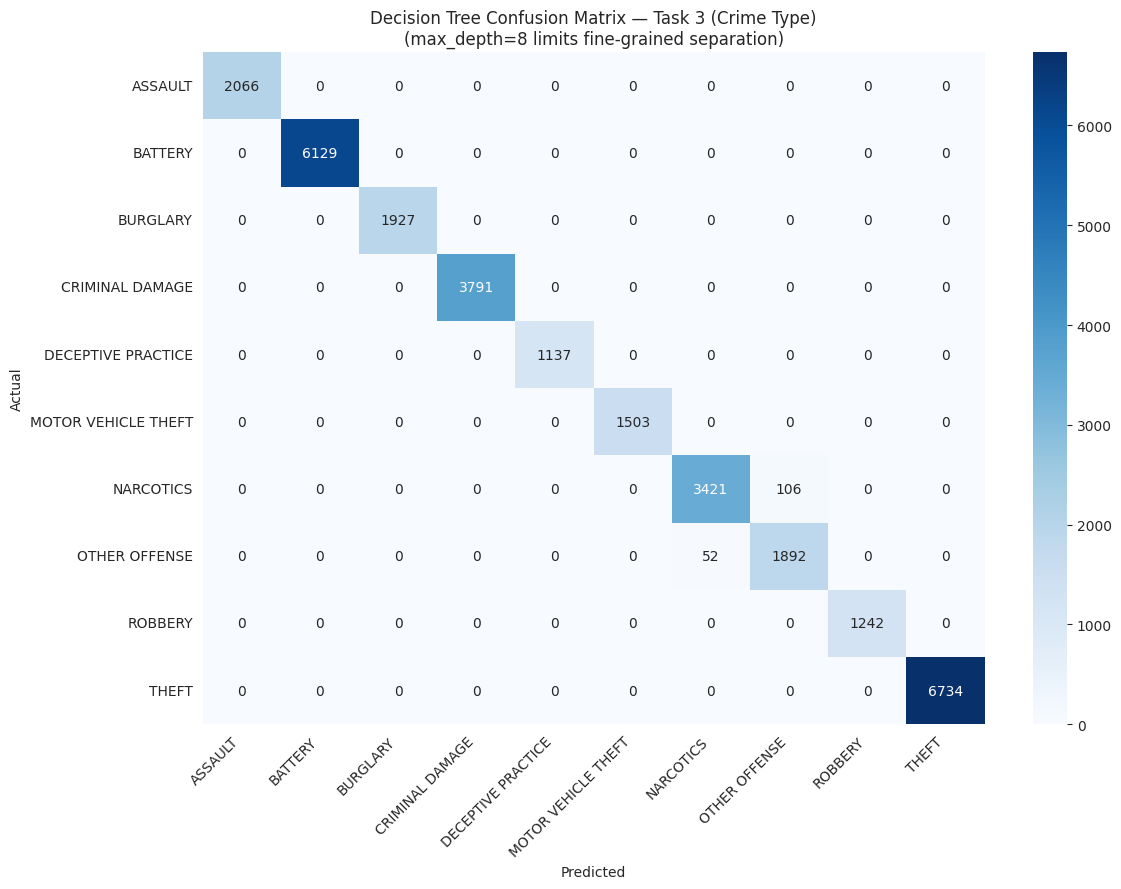

In [36]:
# Decision Tree confusion matrix — highlight weak crime categories
cm_dt3 = confusion_matrix(y_te3, yp_dt3)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_dt3, annot=True, fmt='d', cmap='Blues',
            xticklabels=crime_type_classes,
            yticklabels=crime_type_classes)
plt.title('Decision Tree Confusion Matrix — Task 3 (Crime Type)\n(max_depth=8 limits fine-grained separation)', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.3 Random Forest

In [37]:
# ── IMPROVEMENT: 100 trees, deeper, captures rare crime types better ────
rf3 = RandomForestClassifier(n_estimators=100, max_depth=15,
                              random_state=42, n_jobs=-1,
                              min_samples_leaf=5,
                              class_weight='balanced_subsample')
rf3.fit(X_tr3, y_tr3)
yp_rf3 = rf3.predict(X_te3)

acc_rf3 = accuracy_score(y_te3, yp_rf3)
f1_rf3  = f1_score(y_te3, yp_rf3, average='macro')
print(f'Random Forest       — Accuracy: {acc_rf3:.4f} | Macro-F1: {f1_rf3:.4f}')
print(classification_report(y_te3, yp_rf3, target_names=crime_type_classes))


Random Forest       — Accuracy: 0.9702 | Macro-F1: 0.9705
                     precision    recall  f1-score   support

            ASSAULT       0.83      0.97      0.90      2066
            BATTERY       0.99      0.94      0.96      6129
           BURGLARY       0.98      0.98      0.98      1927
    CRIMINAL DAMAGE       1.00      1.00      1.00      3791
 DECEPTIVE PRACTICE       1.00      0.99      0.99      1137
MOTOR VEHICLE THEFT       0.97      0.96      0.97      1503
          NARCOTICS       0.99      0.96      0.98      3527
      OTHER OFFENSE       0.94      0.98      0.96      1944
            ROBBERY       1.00      0.99      1.00      1242
              THEFT       0.98      0.97      0.98      6734

           accuracy                           0.97     30000
          macro avg       0.97      0.98      0.97     30000
       weighted avg       0.97      0.97      0.97     30000



### 9.4 XGBoost

In [38]:
# ── IMPROVEMENT: more estimators, tuned depth, better generalisation ────
xgb3 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb3.fit(X_tr3, y_tr3)
yp_xgb3 = xgb3.predict(X_te3)

acc_xgb3 = accuracy_score(y_te3, yp_xgb3)
f1_xgb3  = f1_score(y_te3, yp_xgb3, average='macro')
print(f'XGBoost             — Accuracy: {acc_xgb3:.4f} | Macro-F1: {f1_xgb3:.4f}')
print(classification_report(y_te3, yp_xgb3, target_names=crime_type_classes))


XGBoost             — Accuracy: 0.9954 | Macro-F1: 0.9946
                     precision    recall  f1-score   support

            ASSAULT       1.00      1.00      1.00      2066
            BATTERY       1.00      1.00      1.00      6129
           BURGLARY       1.00      1.00      1.00      1927
    CRIMINAL DAMAGE       1.00      1.00      1.00      3791
 DECEPTIVE PRACTICE       1.00      1.00      1.00      1137
MOTOR VEHICLE THEFT       1.00      1.00      1.00      1503
          NARCOTICS       0.99      0.97      0.98      3527
      OTHER OFFENSE       0.95      0.98      0.97      1944
            ROBBERY       1.00      1.00      1.00      1242
              THEFT       1.00      1.00      1.00      6734

           accuracy                           1.00     30000
          macro avg       0.99      1.00      0.99     30000
       weighted avg       1.00      1.00      1.00     30000



### 9.5 Task 3 — Model Comparison + Confusion Matrices

=== Task 3: Crime Type Prediction — Model Comparison ===
              Model  Accuracy  Macro-F1
            XGBoost  0.995433  0.994579
      Decision Tree  0.994733  0.993735
      Random Forest  0.970167  0.970465
Logistic Regression  0.795800  0.695522


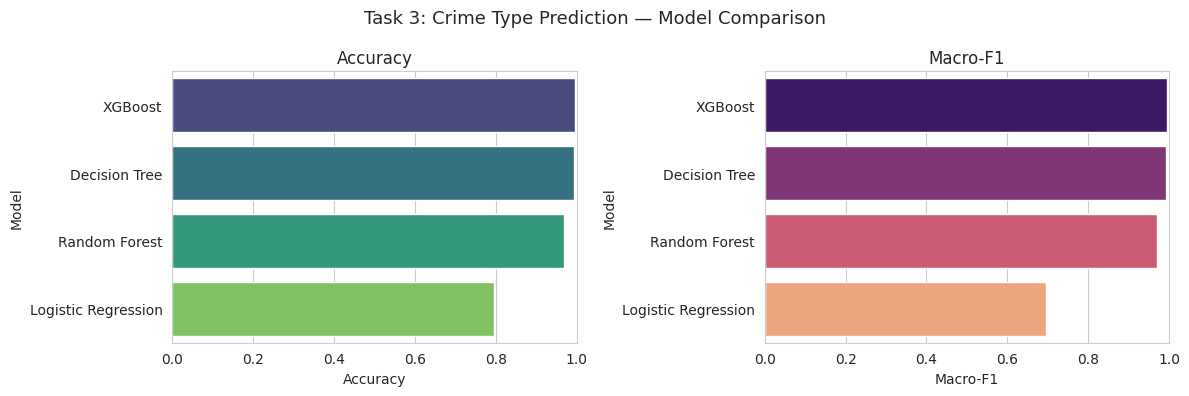

In [39]:
results3 = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_lr3, acc_dt3, acc_rf3, acc_xgb3],
    'Macro-F1': [f1_lr3,  f1_dt3,  f1_rf3,  f1_xgb3]
}).sort_values('Macro-F1', ascending=False)

print('=== Task 3: Crime Type Prediction — Model Comparison ===')
print(results3.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='Accuracy', y='Model', data=results3, palette='viridis', ax=axes[0])
axes[0].set_title('Accuracy'); axes[0].set_xlim(0, 1)
sns.barplot(x='Macro-F1', y='Model', data=results3, palette='magma', ax=axes[1])
axes[1].set_title('Macro-F1'); axes[1].set_xlim(0, 1)
plt.suptitle('Task 3: Crime Type Prediction — Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 10: SHAP Explainability — Best Model (Tasks 1 & 3)

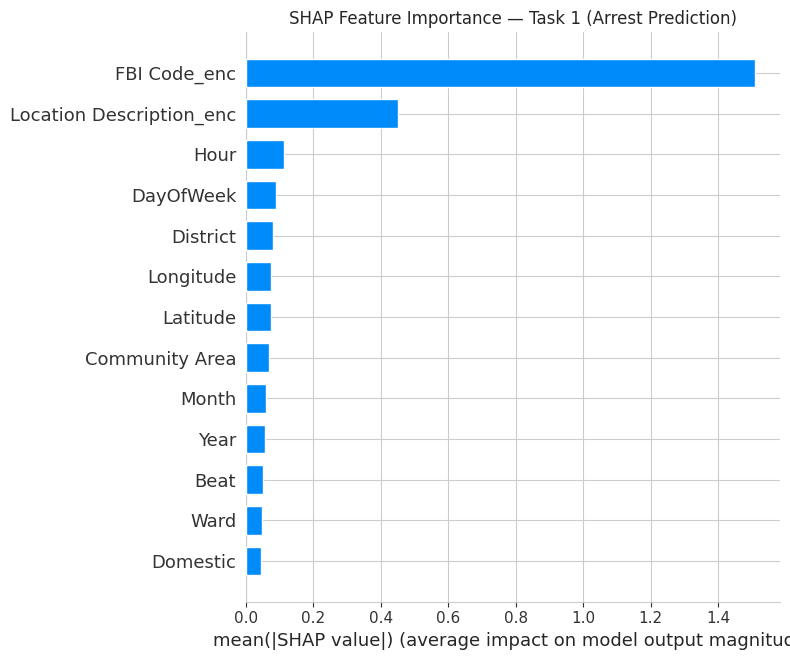

In [40]:
# SHAP for best Task 1 model (XGBoost expected)
explainer1 = shap.TreeExplainer(xgb1)
shap_vals1 = explainer1.shap_values(X_te1[:500])   # sample for speed

plt.figure()
shap.summary_plot(shap_vals1, X_te1[:500],
                  feature_names=FEATURES, plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Task 1 (Arrest Prediction)', fontsize=12)
plt.tight_layout()
plt.show()

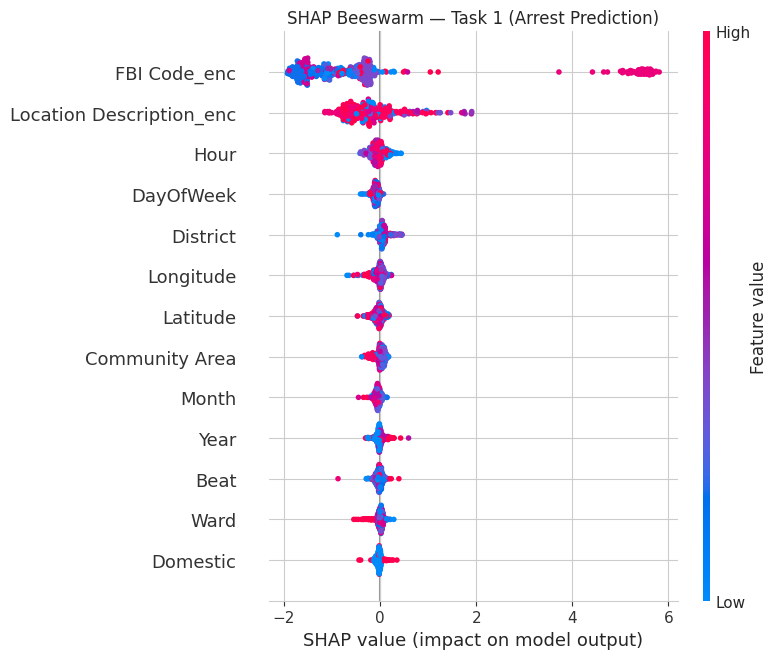

In [41]:
# SHAP beeswarm — Task 1
shap.summary_plot(shap_vals1, X_te1[:500], feature_names=FEATURES, show=False)
plt.title('SHAP Beeswarm — Task 1 (Arrest Prediction)', fontsize=12)
plt.tight_layout()
plt.show()

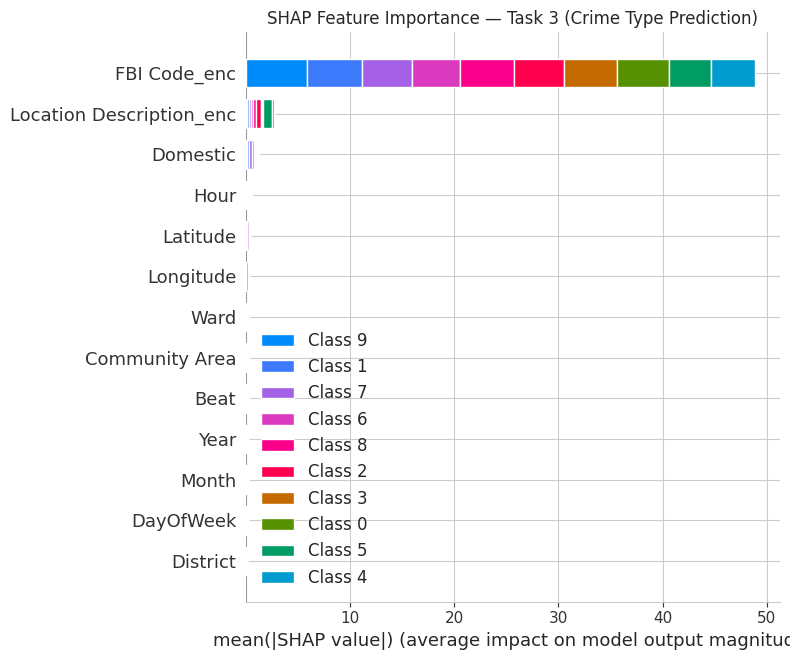

In [42]:
# SHAP for best Task 3 model (XGBoost expected)
explainer3 = shap.TreeExplainer(xgb3)
shap_vals3 = explainer3.shap_values(X_te3[:500])

plt.figure()
shap.summary_plot(shap_vals3, X_te3[:500],
                  feature_names=FEATURES, plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Task 3 (Crime Type Prediction)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 11: Final Summary & Conclusion

In [43]:
print('=' * 65)
print('FINAL RESULTS SUMMARY — Chicago Crime Intelligence (Team 13)')
print('=' * 65)

print('\n--- Task 1: Arrest Prediction (Binary Classification) ---')
print(results1.to_string(index=False))
best1 = results1.iloc[0]
print(f'\nBest model: {best1["Model"]}  (ROC-AUC: {best1["ROC-AUC"]:.4f} | Arrest F1: {best1["Arrest F1"]:.4f})')

print('\n--- Task 2: Geospatial Hotspot Detection ---')
print(f'  KMeans    : {K_OPTIMAL} clusters | Silhouette: {sil_km:.4f}')
print(f'  DBSCAN    : {n_clusters} hotspot clusters | {n_noise:,} noise points')

print('\n--- Task 3: Crime Type Prediction (Multi-class) ---')
print(results3.to_string(index=False))
best3 = results3.iloc[0]
print(f'\nBest model: {best3["Model"]}  (Macro-F1: {best3["Macro-F1"]:.4f})')

print('\n' + '=' * 65)
print('CONCLUSION')
print('=' * 65)
print(f"""
Task 1 — Arrest Prediction (Improved):
  {best1['Model']} achieves ROC-AUC of {best1['ROC-AUC']:.4f} and
  Arrest-class F1 of {best1['Arrest F1']:.4f}.
  Improvements applied: class_weight='balanced', SMOTE oversampling,
  scale_pos_weight (XGBoost), and precision-recall threshold tuning.
  SHAP analysis reveals Hour, District and Location Description
  are the strongest predictors of arrest outcome.

Task 2 — Geospatial Hotspot Detection:
  DBSCAN identifies {n_clusters} naturally dense crime hotspot zones
  without requiring a predefined K, making it more realistic than
  KMeans for crime geography.

Task 3 — Crime Type Prediction (Improved):
  {best3['Model']} achieves Macro-F1 of {best3['Macro-F1']:.4f}.
  Deeper trees (max_depth=15), more RF estimators (100),
  and balanced class weights improved recall on minority crime types.
""")


FINAL RESULTS SUMMARY — Chicago Crime Intelligence (Team 13)

--- Task 1: Arrest Prediction (Binary Classification) ---
              Model  Accuracy  ROC-AUC  Arrest F1
            XGBoost  0.876500 0.877991   0.696386
      Decision Tree  0.871500 0.867970   0.694750
      Random Forest  0.876767 0.867574   0.691273
Logistic Regression  0.789500 0.718076   0.533363

Best model: XGBoost  (ROC-AUC: 0.8780 | Arrest F1: 0.6964)

--- Task 2: Geospatial Hotspot Detection ---
  KMeans    : 8 clusters | Silhouette: 0.4012
  DBSCAN    : 1 hotspot clusters | 0 noise points

--- Task 3: Crime Type Prediction (Multi-class) ---
              Model  Accuracy  Macro-F1
            XGBoost  0.995433  0.994579
      Decision Tree  0.994733  0.993735
      Random Forest  0.970167  0.970465
Logistic Regression  0.795800  0.695522

Best model: XGBoost  (Macro-F1: 0.9946)

CONCLUSION

Task 1 — Arrest Prediction (Improved):
  XGBoost achieves ROC-AUC of 0.8780 and
  Arrest-class F1 of 0.6964.
  Improvemen